<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Represents whether the character is married

* **Is spouse alive**: Represents whether character's spouse is alive

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.65$ --- 5 баллов

2) $0.65 > score \geqslant 0.50$ --- 4 балла

3) $0.50 > score \geqslant 0.45$ --- 3 балла

4) $0.45 > score \geqslant 0.40$ --- 2 балла

5) $0.40 > score \geqslant 0.35$ --- 1 балл

6) $0.35 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

Скачивание в colab

In [732]:
# !gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
# !gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Скачивание на локальный пк

In [733]:
import os

FOLDER = 'content'

# Проверка наличия папки и создание по необходимости
os.makedirs(FOLDER, exist_ok=True)

In [734]:
import gdown

# Скачивание train

FILE_ID = '1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v'
PATH = os.path.join(FOLDER, 'game_of_thrones_train.csv')

# Проверка наличия файла и скачивание по необходимости
if not os.path.exists(PATH):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', PATH, quiet=True)
    print('Файл скачан:', PATH)
else:
    print('Файл уже скачан')

Файл уже скачан


In [735]:
# Скачивание test

FILE_ID = '1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3'
PATH = os.path.join(FOLDER, 'game_of_thrones_test.csv')

# Проверка наличия файла и скачивание по необходимости
if not os.path.exists(PATH):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', PATH, quiet=True)
    print('Файл скачан:', PATH)
else:
    print('Файл уже скачан')

Файл уже скачан


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [736]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [737]:
import warnings
warnings.filterwarnings('ignore')

In [738]:
# PATH = '/content/' # colab
PATH = 'content/' # локальный

In [739]:
data = pd.read_csv(PATH + 'game_of_thrones_train.csv', index_col='S.No')
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


Посмотрите, какие типы данных представлены в нашем датасете

Знакомый нам метод describe() возвращает различную информацию для столбцов с числовыми типами данных, и с типами данных *object*

Давайте посмотрим на вывод для типа данных *object*. Для этого:
- сначала применим метод describe(). Укажем в качестве аргумента тип данных столбцов, статистику по которым мы хотим посмотреть (см. https://pandas.pydata.org/docs/reference/api/pandas.Series.map.html)
- для удобства восприятия транспонируем таблицу

In [740]:
data.describe(include='object').T

,count,unique,top,freq
name,1557,1557,Viserys II Targaryen,1
title,717,195,Ser,306
culture,488,51,Northmen,94
mother,18,16,Rhaenyra Targaryen,2
father,22,19,Daemon Targaryen,2
heir,21,20,Jaehaerys Targaryen,2
house,1176,315,House Frey,89
spouse,200,186,Walder Frey,6


Теперь давайте посмотрим на столбцы с числовыми типами данных. Дополните код ниже. Для удобства восприятия мы транспонировали таблицу и ограничили вывод тремя столбцами - количество строк без NaN, максимальное и минимальное значение (о кастомизации вариантах вывода describe() вы можете почитать в документации по ссылке выше).


In [741]:
data.describe(include='number').T[['count', 'min', 'max']]

,count,min,max
male,1557.0,0.0,1.0
dateOfBirth,279.0,-25.0,299.0
book1,1557.0,0.0,1.0
book2,1557.0,0.0,1.0
book3,1557.0,0.0,1.0
book4,1557.0,0.0,1.0
book5,1557.0,0.0,1.0
isAliveMother,18.0,0.0,1.0
isAliveFather,22.0,0.0,1.0
isAliveHeir,21.0,0.0,1.0


Проверим на наличие дубликатов

In [742]:
data.duplicated().sum()

0

Так мы проверим, есть ли в данных неадекватнные значения.   Большинство числовых столбцов - это числа от 0 до 1. Отрицательные значения `dateOfBirth` не являются ошибкой. Значения age и `numDeadRelations` также выглядят адекватными. Можно переходить к дальнейшим шагам анализа (анонс - а в тестовых данных нас будет ждать сюрприз).

**Задание 1.3.** Предобработка (очистка) данных.

В нашем домашнем задании все пропуски в данных (missing values) уже закодированы как NaN. Проанализируйте, в каких колонках и как часто встречаются NaN значения. Далее вам надо будет принять решение, как их обрабатывать.

Взглянем на общую длину обучающей выборки

In [743]:
len(data)

1557

Теперь посмотрим на количество пропусков в столбцах обучающей выборки

In [744]:
cols_with_missing = data.isna().sum()
cols_with_missing[cols_with_missing > 0]

title             840
culture          1069
dateOfBirth      1278
mother           1539
father           1535
heir             1536
house             381
spouse           1357
isAliveMother    1539
isAliveFather    1535
isAliveHeir      1536
isAliveSpouse    1357
age              1278
dtype: int64

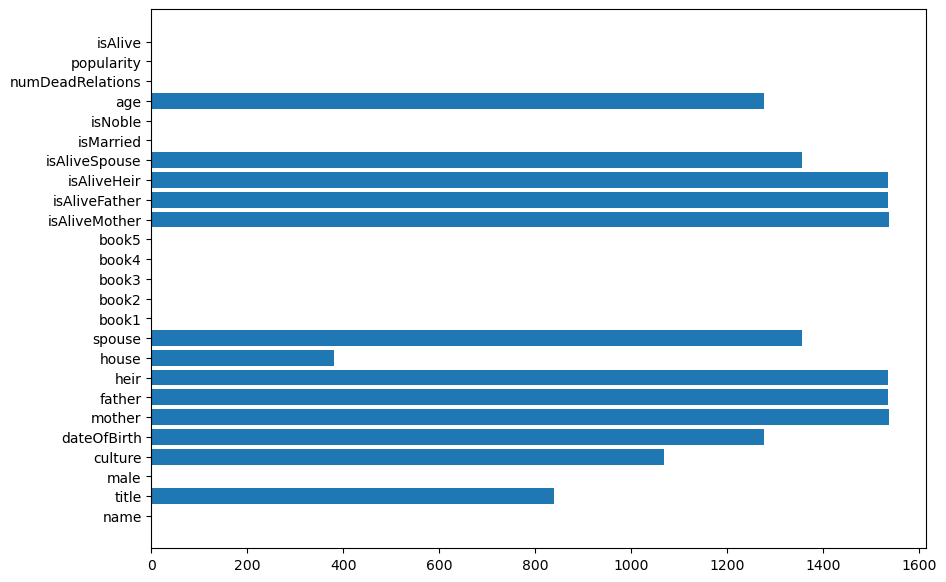

In [745]:
plt.figure(figsize=(10, 7))
plt.barh(cols_with_missing.index, cols_with_missing.values)

plt.show();

В этом задании удалять строки с NaN (dropna) мы не будем по следующим причинам:
- в обучающем датасете много признаков с большим количество пропусков. Если удалять все строки с NaN, то размер выборки сильно уменьшится. Мы потеряем много данных, которые можно было бы использовать для построения более точной модели.
- тестовом датасете также много признаков с NaN (вы можете в этом убедиться, если скачаете датасет и совершите с ним те же действия, что выше проделали с обучаюшим датасетом). Поэтому нам все-равно придется придумать способ кодировать NaN, чтобы модель делала прогнозы для всех персонажей из тестового датасета. Для этого нам потребуется сохранять, а не удалять данные в обучающем датасете.     



Как вы могли заметить, в наших данных очень много пропущенных значений, причём в некоторых случая пропущена **большая** часть значений. Поэтому заполнять по умолчанию медианой/средним/модой в данном случае - не самый лучший способ (однако, это довольно часто используемый метод заполнения, который может пригодиться вам в будущем)

Ниже мы посмотрим, как можно работать с признаками с большим количеством пропущенных значений.

**Задание 1.4.** Числовые признаки

У нас есть **признак popularity**. Постройте гистограмму распределения данного признака с количеством интервалов (bins), равным 50 (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.hist.html)

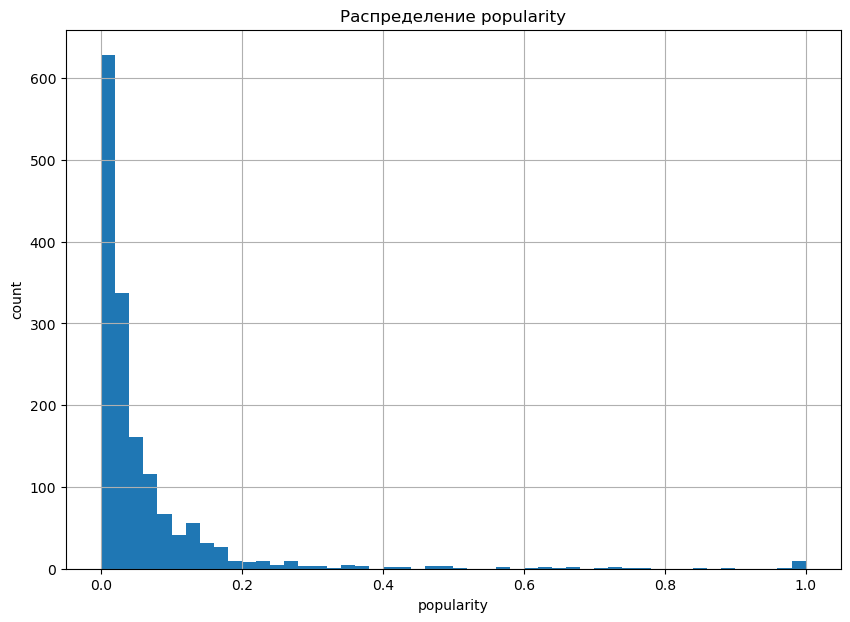

In [746]:
plt.figure(figsize=(10, 7))

plt.hist(x=data['popularity'], bins=50)
plt.xlabel('popularity')
plt.ylabel('count')
plt.title('Распределение popularity')
plt.grid(True)

plt.show();

Распределение сильно несимметрично. Можно преобразовать данный признак, например, по формуле `np.log10(data["popularity"]*M+1)` (добавляем 1 ради логарифма, так как для некоторых персонажей `popularity==0`). В качестве M можно попробовать, например, M=100 или другое число.

При желании для `popularity` вы можете использовать свой способ шкалирования признаков с несимметричным распределением.


In [747]:
import numpy as np

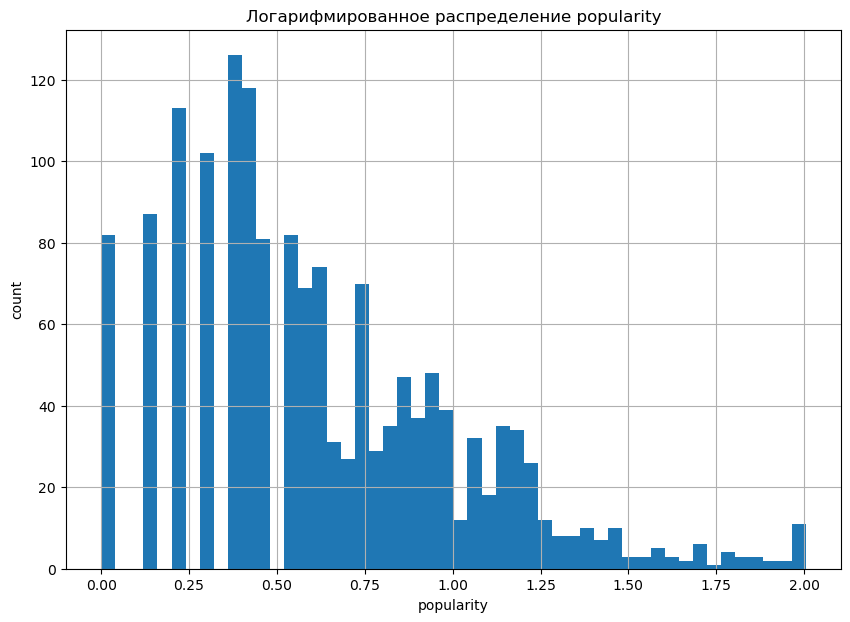

In [748]:
M = 100

data['popularity_log'] = np.log10(data['popularity'] * M + 1) # добавим в наш датасет

plt.figure(figsize=(10, 7))
plt.hist(x=data['popularity_log'], bins=50)
plt.xlabel('popularity')
plt.ylabel('count')
plt.title('Логарифмированное распределение popularity')
plt.grid(True)

plt.show();

В качестве альтернативного подхода вы можете попробовать дискретизацию признака popularity на основе квантилей (quantile binning), используя функцию qcut() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html). В этом случае вы преобразуете числовой признак popularity в категориальный, для которого в дальнейшем надо будет применить one-hot кодирование.

In [749]:
# Признак popularity разобьем на 5 частей

data['popularity_qcut'] = pd.qcut(data['popularity'], q=5, labels=False, duplicates='drop')

In [750]:
data[['popularity', 'popularity_log', 'popularity_qcut']].sample(10)

,popularity,popularity_log,popularity_qcut
S.No,,,
1143,0.103679,1.055680,4
21,0.020067,0.478089,2
45,0.013378,0.368806,1
1288,0.030100,0.603148,2
678,0.036789,0.670147,3
210,0.023411,0.523894,2
1334,0.020067,0.478089,2
717,0.016722,0.426876,1
1264,0.083612,0.971332,4


Теперь давайте обработаем **признак numDeadRelations**.
Посмотрите на частотное распределение этого признака. Лишь для малого числа персонажей `numDeadRelations>0`.

Создайте признак `boolDeadRelations`. Давайте упростим признак `numDeadRelations`, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. `numDeadRelations > 0`, и те, у которых не было, т.е. `numDeadRelations = 0`.

In [751]:
data['boolDeadRelations'] = (data['numDeadRelations'] > 0).astype(int)

In [752]:
data[['numDeadRelations', 'boolDeadRelations']].sample(10, random_state=4) # random_state=4 - для просмотра отработки нашего преобразования

,numDeadRelations,boolDeadRelations
S.No,,
551,0,0
1468,1,1
1404,0,0
1190,0,0
1499,0,0
32,0,0
1335,0,0
1481,0,0
842,1,1


Наконец, давайте посмотрим на **признак age**. В нем очень много пропущенных значений. Для того, чтобы использовать в модели информацию о возрасте персонажа, мы создадим два новых признака: `age_value` и `age_no_data`

- Там где возраст указан, age_value принимает значение `age`, а `age_no_data` - значение 0.
- Там где возраст не указан, `age_value` принимает значение 0, а `age_no_data` - значение 1.  

Фактически, в переменной `age` мы заменяем NaN на 0, но одновременно добавляем в модель еще один бинарный признак `age_no_data`, несущий информацию о том, у каких персонажей не был указан возраст:        

In [753]:
data['age_value'] = data['age'].fillna(0)
data['age_no_data'] = [1 if np.isnan(x) else 0 for x in data['age']]

In [754]:
data[['age', 'age_value', 'age_no_data']].sample(10, random_state=0)

,age,age_value,age_no_data
S.No,,,
320,NaN,0.0,1
1265,NaN,0.0,1
799,NaN,0.0,1
580,NaN,0.0,1
415,NaN,0.0,1
495,NaN,0.0,1
619,10.0,10.0,0
1152,43.0,43.0,0
1258,NaN,0.0,1


Этот способ чем-то похож на работу с категориальной переменными с пропущенными значениями, когда мы добавляем еще одну категорию no_data и заменяем NaN на значение этой категории.

Если вы заходите похожим образом образом обработать признак `dateOfBirth`, **обратите внимание**, что у одних и тех же персонажей не указан и возраст, и год рождения.
То есть созданные признаки `age_no_data` и `dateOfBirth_no_data` будут полностью совпадать, и в модель надо будет включать только один из признаков: или `age_no_data`, или `dateOfBirth_no_data`.

**Задание 1.5.** Категориальные признаки с большим количеством категорий

**Признак culture** содержит информацию о принадлежности к одному из народов во вселенной Игры Престолов.

Давайте посмотрим, какие значения принимает данный признак. По умолчанию метод `value_counts()` игнорирует пропуски в данных, поэтому используем этот метод с параметром **dropna** со значением **False** (см. https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.value_counts.html)

In [755]:
data['culture'].value_counts(dropna=False)

culture
NaN                        1069
Northmen                     94
Ironborn                     91
Free Folk                    45
Braavosi                     39
Valyrian                     28
Dornish                      17
Dothraki                     17
Ghiscari                     17
Reach                        13
Vale mountain clans          12
Valemen                      10
Rivermen                     10
northmen                      9
Westerman                     8
Free folk                     7
Tyroshi                       6
Qartheen                      5
Summer Isles                  4
Stormlands                    4
Astapori                      4
Ironmen                       3
Dornishmen                    3
Northern mountain clans       3
Westermen                     3
Westeros                      3
Myrish                        2
Crannogmen                    2
Meereenese                    2
First Men                     2
westermen                     2


In [756]:
# Количество уникальных значений

data['culture'].nunique()

51

Из полученного частотного распределения видно, что для большого числа персонажей значения данного признака не указаны. Также есть много редких значений признака, которые в выборке повторяются один или несколько раз. Причина отчасти в том, что один и тот же народ упоминается в нашем датасете под разными названиями.

Данную проблему мы попытаемся решить, сгруппировав народы в более крупные категории. Так мы одновременно решим проблему того, что один и тот же народ назван в выборке разными способами.

Предоженный вариант группировки имеет определенную логику. Выделяются следующие группы:
- старые нации, которые уже не сущевали как отдельные народы на момент повествования основной линии повествования романов, но отдельные потомки могли еще быть живы
- народы, проживающие в королевствах континента Весторос (для каждого королевства - своя группа)
- народы континента Эссос
- прочие народы

In [757]:
cultures_grouped = {
    'Old Nations': ['valyrian', 'first men', 'andal', 'andals', 'rhoynar'],
    'the North': ['northmen', 'northern mountain clans', 'crannogmen'],
    'the Iron Islands': ['ironborn', 'ironborn', 'ironmen'],
    'the Mountain and the Vale': ['valemen', 'vale', 'vale mountain clans',
                              'sistermen'],
    'the Isles and Rivers': ['riverlands', 'rivermen'],
    'the Rock': ['westerman', 'westermen', 'westerlands'],
    'the Stormlands': ['stormlander', 'stormlands'],
    'the Reach': ['reach', 'reachmen', 'the reach'],
    'Dorne': ['dornish', 'dornishmen', 'dorne'],
    'Essos Nations': ['astapor', 'astapori', 'braavosi', 'braavos', 'tyroshi', 'lysene', 'lyseni',
                      'myrish', 'pentoshi', 'qartheen', 'qarth', 'dothraki',
                      'lhazarene', 'lhazareen','meereen', 'meereenese',
                      'norvoshi', 'qohor', 'summer isles', 'summer islands',
                      'summer islander', 'asshai', "asshai'i", 'norvos', 'ghiscari',
                      'ghiscaricari'],
    'Other Nations': ['ibbenese', 'westeros', 'free folk', 'wildling', 'wildlings', 'naathi']}

**Обратите внимание, что некоторые варианты названий народов встречаются только в тестовых данных, и не встречаются в обучающих данных.** Такая ситуация нередко случается на практике. Поэтому, после обработки обучающих данных и обучения модели важно задать для модели правило, как она должна обрабатывать "незнакомые" категории в категориальных признаках. Например, можно относить объекты с "незнакомой" категорией к некоторой существующей категории или указать формулу расчета для "незнакомой" категории.     

Предложенный вам словарь `cultures_grouped` составлен по всем значениям признака `culture`, встречающимся в тренировочном либо в тестовом датасете. Здесь важно, что все укрупненные категории (ключи/keys словаря `cultures_grouped`) представлены в обоих датасетах, а уникальные для тестового датасета названия народов - это отдельные названия народов внутри укрупненных категорий (значения/values словаря). Поэтому, когда вы будете работать с тестовыми - просто применяйте этот словарь без указания правила обработки "незнакомых" категорий.

Давайте приступим к кодировке значений признака culture.
Для этого сначала инвертируем словарь *cultures_grouped*

In [758]:
#Довольно просто инвертировать словарь, где ключу соответствует одно значение
#В нашем случае ключу соответствует список значений.
#Ниже показан пример, как можно инвертировать такой словарь

d = {'A': ['a1', 'a2', 'a3'],
     'B': ['b1', 'b2', 'b3', 'b4']}

d_inverted = {}
for k in d.keys():
  for v in d[k]:
      d_inverted.update({v:k})

d_inverted

{'a1': 'A', 'a2': 'A', 'a3': 'A', 'b1': 'B', 'b2': 'B', 'b3': 'B', 'b4': 'B'}

In [759]:
# По аналогии с примером выше инвертируйте словарь cultures_grouped
cultures_grouped_inverted = {}
for group, values in cultures_grouped.items():
    for val in values:
        cultures_grouped_inverted[val] = group

In [760]:
cultures_grouped_inverted

{'valyrian': 'Old Nations',
 'first men': 'Old Nations',
 'andal': 'Old Nations',
 'andals': 'Old Nations',
 'rhoynar': 'Old Nations',
 'northmen': 'the North',
 'northern mountain clans': 'the North',
 'crannogmen': 'the North',
 'ironborn': 'the Iron Islands',
 'ironmen': 'the Iron Islands',
 'valemen': 'the Mountain and the Vale',
 'vale': 'the Mountain and the Vale',
 'vale mountain clans': 'the Mountain and the Vale',
 'sistermen': 'the Mountain and the Vale',
 'riverlands': 'the Isles and Rivers',
 'rivermen': 'the Isles and Rivers',
 'westerman': 'the Rock',
 'westermen': 'the Rock',
 'westerlands': 'the Rock',
 'stormlander': 'the Stormlands',
 'stormlands': 'the Stormlands',
 'reach': 'the Reach',
 'reachmen': 'the Reach',
 'the reach': 'the Reach',
 'dornish': 'Dorne',
 'dornishmen': 'Dorne',
 'dorne': 'Dorne',
 'astapor': 'Essos Nations',
 'astapori': 'Essos Nations',
 'braavosi': 'Essos Nations',
 'braavos': 'Essos Nations',
 'tyroshi': 'Essos Nations',
 'lysene': 'Essos Na

Теперь создадим новый столбец с укрупненными значениями culture.

Для этого будем использовать метод `map()` с инвертированным словарем в качестве аргумента (https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.map.html)

Обратите внимание, что в словаре названия народов указаны в нижнем регистре. А в датасете используется как нижний, так и верхний регистр. Поэтому перед применением метода `map()` переведем значения столбца culture в нижний регистр при помощи метода `str.lower()` (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.Series.str.lower.html).

In [761]:
data['culture_grouped'] = data['culture'].str.lower().map(cultures_grouped_inverted)

Осталось заменить все NaN в созданном столбце на категорию `culture_no_data`:

In [762]:
data['culture_grouped'] = data['culture_grouped'].fillna('culture_no_data')

In [763]:
data['culture_grouped'].value_counts()

culture_grouped
culture_no_data              1069
Essos Nations                 109
the North                     108
the Iron Islands               95
Other Nations                  57
Old Nations                    32
the Mountain and the Vale      25
Dorne                          21
the Rock                       14
the Reach                      13
the Isles and Rivers           10
the Stormlands                  4
Name: count, dtype: int64

In [764]:
data['culture_grouped'].nunique()

12

Распределение сгруппированной переменной выглядит гораздо лучше. Но по прежнему есть несколько слабо представленых групп.

Дальнейшую работу с этим признаком проводите на свое усмотрение для повышения качества прогноза модели. Например, можно объединить несколько слабо представленных категорий в одну или применить другой подход.

Создадим столбец с данными из столбца culture_grouped в котором несколько слабо представленых групп объединены в одну группу 'culture_rare'

In [765]:
culture_counts = data['culture_grouped'].value_counts()
rare_cultures = culture_counts[culture_counts < 15].index

data['culture_grouped_truncated'] = np.where(data['culture_grouped'].isin(rare_cultures), 'culture_rare', data['culture_grouped'])

In [766]:
data['culture_grouped_truncated'].value_counts()

culture_grouped_truncated
culture_no_data              1069
Essos Nations                 109
the North                     108
the Iron Islands               95
Other Nations                  57
culture_rare                   41
Old Nations                    32
the Mountain and the Vale      25
Dorne                          21
Name: count, dtype: int64

**Задание 1.6.** Категориальные признаки в линейных моделях

Для включения категориальных признаков в линейную модель их нужно преобразовать в числовые признаки.

Если признак принимает одно из двух возможных значений (например, персонаж "появляется" или "не появляется" в 1-й книге), он напрямую кодируется в бинарный признак ("появляется" -> 1, "не появляется" -> 0). Если признак принимает больше двух значений, его можно преобразовать в несколько бинарных при помощи one-hot преобразования. В некоторых случаях бывает полезно объединить некоторые категории, как мы это поступили с признаком *culture*.

Порядковых признаков у нас в задаче нет, поэтому рассматривать их здесь мы не будем.

Для того, чтобы найти все порядковые признаки, посмотрим на количество уникальных значений, которые встречаются в столбцах. Для столбцов с типом object количество уникальных значений мы выводили  при помощи метода `describe()` в задании 1.2.

Чтобы посмотреть количество уникальных значений для всех столбцов, можно воспользоваться методом nunique() (https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.nunique.html)

In [767]:
# Количество уникальнх значений в каждом столбце
data.nunique().sort_values(ascending=False)

name                         1557
house                         315
title                         195
spouse                        186
popularity_log                117
popularity                    117
dateOfBirth                   105
age_value                      72
age                            72
culture                        51
heir                           20
father                         19
mother                         16
numDeadRelations               14
culture_grouped                12
culture_grouped_truncated       9
popularity_qcut                 5
isAliveMother                   2
isAliveHeir                     2
isAliveSpouse                   2
isMarried                       2
isNoble                         2
book5                           2
book4                           2
book3                           2
isAlive                         2
book2                           2
boolDeadRelations               2
book1                           2
age_no_data   

In [768]:
# Для числовых столбцов можно вывести в одну таблицу более детальную статистику, объединив выводы describe() и nunique()
# Код ниже требуется дополнить по аналогии с заданием 1.2.
data.describe(include='number').T[['count', 'min', 'max', 'mean']].assign(N_unique_values = data.nunique())

,count,min,max,mean,N_unique_values
male,1557.0,0.0,1.000000,0.590880,2
dateOfBirth,279.0,-25.0,299.000000,247.551971,105
book1,1557.0,0.0,1.000000,0.138728,2
book2,1557.0,0.0,1.000000,0.327553,2
book3,1557.0,0.0,1.000000,0.431599,2
book4,1557.0,0.0,1.000000,0.562620,2
book5,1557.0,0.0,1.000000,0.330122,2
isAliveMother,18.0,0.0,1.000000,0.666667,2
isAliveFather,22.0,0.0,1.000000,0.227273,2
isAliveHeir,21.0,0.0,1.000000,0.666667,2


Посмотрев на количество уникальных значений мы можем выделить категориальные признаки. Например, `popularity` принимает значения от 0 до 1, но это непрерывный числовой признак. Остальные признаки со значениями от 0 до 1 - принимают только два значения, то есть являются бинарными.

Бинарные признаки без NaN полностью готовы для включения в модель. Некоторые бинарные признаки содержат пропуски, поэтому, если вы захотите включить их в модель, их потребуется обработать.

In [769]:
# Создадим новые признаки на основе существующих по принципу работы с колонкой 'age'

for col in ['isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse']:
    data[col + '_value'] = data[col].fillna(0)
    data[col + '_no_data'] = data[col].isna().astype(int)

Для бинарных признаков их связь с зависимой переменной можно прикинуть по таблице корреляций. Для категориальных признаков с количеством значений больше двух (или с двумя значениями и NaN) можно сделать one-hot преобразования и посчитать корреряцию зависимой переменной с набором сгенерированных бинарных признаков.
В качестве альтернативного подхода можно использовать сравнение средних значений зависимой переменной для разных категорий исследуемого признака. Чем сильнее различаются средние значения целевой переменной между категориями, тем вероятнее, что данный признак связан с зависимой переменной.

In [770]:
# попробуйте провести сравнение средних зависимой пременной isAlive для признака isAliveSpouse
# одним из приведенных ниже способов:

# data.groupby('НАЗВАНИЕ ПРИЗНАКА', dropna = False)['isAlive'].mean()
# pd.pivot_table(data = data, values = 'isAlive', index = 'НАЗВАНИЕ ПРИЗНАКА', aggfunc=['mean', 'count'], dropna=False)

In [771]:
display(pd.DataFrame(data.groupby('isAliveSpouse', dropna=False)['isAlive'].mean()).reset_index())

,isAliveSpouse,isAlive
0,0.0,0.619048
1,1.0,0.753165
2,NaN,0.786293


In [772]:
pivot_isAliveSpouse_isAlive = pd.pivot_table(data, values='isAlive', index='isAliveSpouse', aggfunc=['mean', 'count'], dropna=False).reset_index()
pivot_isAliveSpouse_isAlive.columns = ['_'.join(col).strip() for col in pivot_isAliveSpouse_isAlive.columns.values]
display(pivot_isAliveSpouse_isAlive)

,isAliveSpouse_,mean_isAlive,count_isAlive
0,0.0,0.619048,42
1,1.0,0.753165,158
2,NaN,0.786293,1357


Посмотрим на оставшиеся с пропусками колонки 

In [773]:
cols_with_missing = data.isna().sum()
cols_with_missing[cols_with_missing > 0]

title             840
culture          1069
dateOfBirth      1278
mother           1539
father           1535
heir             1536
house             381
spouse           1357
isAliveMother    1539
isAliveFather    1535
isAliveHeir      1536
isAliveSpouse    1357
age              1278
dtype: int64

In [774]:
cols_to_drop = []

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик. Не забудьте, что потом аналогичным образом вам надо будет преобразовывать тестовый датасет, используя тот же алгоритм кодирования признаков.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

Необходимо выделить информативные признаки и игнорировать признаки-идентификаторы

In [775]:
print(data.columns)

data.head()

Index(['name', 'title', 'male', 'culture', 'dateOfBirth', 'mother', 'father',
       'heir', 'house', 'spouse', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive', 'popularity_log', 'popularity_qcut', 'boolDeadRelations',
       'age_value', 'age_no_data', 'culture_grouped',
       'culture_grouped_truncated', 'isAliveMother_value',
       'isAliveMother_no_data', 'isAliveFather_value', 'isAliveFather_no_data',
       'isAliveHeir_value', 'isAliveHeir_no_data', 'isAliveSpouse_value',
       'isAliveSpouse_no_data'],
      dtype='object')


,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,culture_grouped,culture_grouped_truncated,isAliveMother_value,isAliveMother_no_data,isAliveFather_value,isAliveFather_no_data,isAliveHeir_value,isAliveHeir_no_data,isAliveSpouse_value,isAliveSpouse_no_data
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,culture_no_data,culture_no_data,1.0,0,0.0,0,0.0,0,0.0,1
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,the Isles and Rivers,culture_rare,0.0,1,0.0,1,0.0,1,1.0,0
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,culture_no_data,culture_no_data,0.0,1,0.0,1,0.0,1,0.0,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,culture_no_data,culture_no_data,0.0,1,0.0,1,0.0,1,0.0,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,Dorne,Dorne,0.0,1,0.0,1,0.0,1,1.0,0


In [776]:
data.select_dtypes(exclude='number').nunique()

name                         1557
title                         195
culture                        51
mother                         16
father                         19
heir                           20
house                         315
spouse                        186
culture_grouped                12
culture_grouped_truncated       9
dtype: int64

У признака house много уникальных значений. Обработаем значения признака аналогично обработке признака culture.

In [777]:
data['house'].isna().sum()

381

Но для начала обработаем пропущенные значения

In [778]:
# Посмотрим на строки с отсутвующими значениями в колонке 'house'

# data[(data['house'].isna())].head(50)
data[(data['house'].isna())].head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,culture_grouped,culture_grouped_truncated,isAliveMother_value,isAliveMother_no_data,isAliveFather_value,isAliveFather_no_data,isAliveHeir_value,isAliveHeir_no_data,isAliveSpouse_value,isAliveSpouse_no_data
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,culture_no_data,culture_no_data,1.0,0,0.0,0,0.0,0,0.0,1
6,Tommen Baratheon,NaN,1,NaN,NaN,Cersei Lannister,Robert Baratheon,Myrcella Baratheon,NaN,NaN,...,culture_no_data,culture_no_data,1.0,0,1.0,0,1.0,0,0.0,1
8,Viserys I Targaryen,NaN,1,NaN,NaN,Alyssa Targaryen,Baelon Targaryen,Rhaenyra Targaryen,NaN,NaN,...,culture_no_data,culture_no_data,1.0,0,1.0,0,1.0,0,0.0,1
9,Wilbert,Ser,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,culture_no_data,culture_no_data,0.0,1,0.0,1,0.0,1,0.0,1
12,Will (orphan),NaN,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,culture_no_data,culture_no_data,0.0,1,0.0,1,0.0,1,0.0,1


In [779]:
# data['father'].unique()
# data['heir'].unique()
# data['spouse'].unique()
# data['mother'].unique()

Можно заметить, что в некоторых строках заполнены поля 'father' и/или 'mother' и/или 'heir'. Заполним отсутствующие значения в колонке 'house' значениями из колонок 'father' или 'mother' или 'heir'

In [780]:
# Извлекаем последнее слово (фамилию) в значениях колонки 'father' или 'mother' и возвращаем готовое значение для колонки 'house'

def extract_surename(value):
    if pd.isna(value):
        return None
    return 'House ' + value.strip().split()[-1]

In [781]:
house_with_missing = data['house'].isna() # только строки с пропущенными значениями
father_house = data.loc[house_with_missing, 'father'].apply(extract_surename) # фамилии по отцу
heir_house = data.loc[house_with_missing, 'heir'].apply(extract_surename) # фамилии по наследникам
spouse_house = data.loc[house_with_missing, 'spouse'].apply(extract_surename) # фамилии по супругу/супруге
mother_house = data.loc[house_with_missing, 'mother'].apply(extract_surename) # фамилии по матери


In [782]:
# Заполняем попущенные значения по приоритету father-heir-spouse-mother-no_data

data.loc[house_with_missing, 'house'] = data.loc[house_with_missing, 'house'].\
    fillna(father_house).\
        fillna(heir_house).\
            fillna(spouse_house).\
                fillna(mother_house). \
                    fillna('house_no_data')

In [783]:
house_counts = data['house'].value_counts(dropna=False)
house_counts

house
house_no_data                   345
House Frey                       89
Night's Watch                    88
House Stark                      58
House Targaryen                  54
                               ... 
House Staedmon                    1
City Watch of King's Landing      1
House Cockshaw                    1
House Graceford                   1
House Moore                       1
Name: count, Length: 326, dtype: int64

In [784]:
# data[(data['house'] == 'house_no_data')]

In [785]:
# house_counts[house_counts > 5].index.tolist()

house_counts[house_counts > 5]

house
house_no_data                     345
House Frey                         89
Night's Watch                      88
House Stark                        58
House Targaryen                    54
House Lannister                    36
House Tyrell                       33
House Greyjoy                      31
House Osgrey                       20
Faith of the Seven                 15
House Hightower                    12
House Botley                       12
House Arryn                        11
House Martell                      11
House Florent                      10
House Crakehall                    10
House Waynwood                      9
House Bracken                       9
House Baratheon                     9
House Brax                          8
House Velaryon                      8
House Tully                         8
Stone Crows                         8
House Westerling                    8
House Wylde                         8
House Paege                         7
House 

In [786]:
rare_houses = house_counts[house_counts < 15].index

data['house_grouped'] = np.where(data['house'].isin(rare_houses), 'house_rare', data['house'])

In [787]:
data['house_grouped'].value_counts(dropna=False)

house_grouped
house_rare            788
house_no_data         345
House Frey             89
Night's Watch          88
House Stark            58
House Targaryen        54
House Lannister        36
House Tyrell           33
House Greyjoy          31
House Osgrey           20
Faith of the Seven     15
Name: count, dtype: int64

Для дальнейшей обработки возьмем категориальные признаки: culture_grouped, culture_grouped_truncated и house_grouped.


In [788]:
data.shape

(1557, 41)

In [789]:
from sklearn.preprocessing import OneHotEncoder

In [790]:
cat_cols = ['culture_grouped', 'culture_grouped_truncated', 'house_grouped']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

ohe_encoded = ohe.fit_transform(data[cat_cols])

data_encoded = pd.DataFrame(
    ohe_encoded, 
    columns=ohe.get_feature_names_out(cat_cols), 
    index=data.index)

data = pd.concat([data, data_encoded], axis=1)

In [791]:
data.shape

(1557, 73)

Корреляционный анализ

In [792]:
# Числовые признаки

data.select_dtypes(include='number').columns

Index(['male', 'dateOfBirth', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity',
       'isAlive', 'popularity_log', 'popularity_qcut', 'boolDeadRelations',
       'age_value', 'age_no_data', 'isAliveMother_value',
       'isAliveMother_no_data', 'isAliveFather_value', 'isAliveFather_no_data',
       'isAliveHeir_value', 'isAliveHeir_no_data', 'isAliveSpouse_value',
       'isAliveSpouse_no_data', 'culture_grouped_Dorne',
       'culture_grouped_Essos Nations', 'culture_grouped_Old Nations',
       'culture_grouped_Other Nations', 'culture_grouped_culture_no_data',
       'culture_grouped_the Iron Islands',
       'culture_grouped_the Isles and Rivers',
       'culture_grouped_the Mountain and the Vale',
       'culture_grouped_the North', 'culture_grouped_the Reach',
       'culture_grouped_the Rock', 'culture_grouped_the Stormlands',
       'cultu

In [793]:
data.corr(numeric_only=True).shape

(62, 62)

In [794]:
data.corr(numeric_only=True)

,male,dateOfBirth,book1,book2,book3,book4,book5,isAliveMother,isAliveFather,isAliveHeir,...,house_grouped_House Frey,house_grouped_House Greyjoy,house_grouped_House Lannister,house_grouped_House Osgrey,house_grouped_House Stark,house_grouped_House Targaryen,house_grouped_House Tyrell,house_grouped_Night's Watch,house_grouped_house_no_data,house_grouped_house_rare
male,1.000000,-0.053117,0.050526,0.024079,-0.008100,-0.101674,0.023022,NaN,NaN,NaN,...,-0.037072,0.034438,-0.028437,0.013716,0.039517,0.022078,-0.031734,0.067896,-0.049864,0.011461
dateOfBirth,-0.053117,1.000000,0.097634,0.466285,0.503627,0.612802,0.222051,NaN,NaN,NaN,...,0.300748,0.019961,0.070338,-0.145852,0.059909,-0.564678,0.070023,0.029917,0.033242,0.026236
book1,0.050526,0.097634,1.000000,0.278116,0.145458,-0.009461,0.180542,NaN,-0.118345,NaN,...,0.013232,-0.043901,0.123704,-0.045782,0.146718,-0.015144,0.057044,0.078788,-0.062014,-0.064360
book2,0.024079,0.466285,0.278116,1.000000,0.380968,0.102247,0.135720,NaN,-0.118345,NaN,...,0.258476,0.086659,0.029212,-0.079614,0.209576,-0.087416,-0.017190,0.012892,-0.151594,-0.049575
book3,-0.008100,0.503627,0.145458,0.380968,1.000000,0.329153,0.226547,NaN,NaN,NaN,...,0.204366,-0.068502,0.003990,-0.099401,-0.096086,-0.115561,0.123855,0.179801,-0.146440,0.036051
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
house_grouped_House Targaryen,0.022078,-0.564678,-0.015144,-0.087416,-0.115561,-0.172523,-0.050956,8.770580e-02,-0.431187,-0.500000,...,-0.046671,-0.027016,-0.029161,-0.021622,-0.037285,1.000000,-0.027892,-0.046393,-0.101129,-0.191875
house_grouped_House Tyrell,-0.031734,0.070023,0.057044,-0.017190,0.123855,0.075809,0.019970,NaN,NaN,NaN,...,-0.036232,-0.020973,-0.022639,-0.016786,-0.028945,-0.027892,1.000000,-0.036016,-0.078510,-0.148958
house_grouped_Night's Watch,0.067896,0.029917,0.078788,0.012892,0.179801,-0.030897,0.106160,NaN,NaN,NaN,...,-0.060265,-0.034885,-0.037655,-0.027920,-0.048144,-0.046393,-0.036016,1.000000,-0.130584,-0.247760
house_grouped_house_no_data,-0.049864,0.033242,-0.062014,-0.151594,-0.146440,-0.109436,-0.144341,NaN,NaN,NaN,...,-0.131368,-0.076043,-0.082081,-0.060861,-0.104947,-0.101129,-0.078510,-0.130584,1.000000,-0.540080


In [795]:
cols_with_missing = data.isna().sum()
cols_with_missing[cols_with_missing > 0]

title             840
culture          1069
dateOfBirth      1278
mother           1539
father           1535
heir             1536
spouse           1357
isAliveMother    1539
isAliveFather    1535
isAliveHeir      1536
isAliveSpouse    1357
age              1278
dtype: int64

Выберем количественные признаки для корреляционного анализа

In [796]:
num_cols = ['male', 'book1', 'book2', 'book3', 'book4', 'book5',
       'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'numDeadRelations', 'popularity',
       'popularity_log', 'popularity_qcut', 'boolDeadRelations',
       'age_value', 'age_no_data', 'isAliveMother_value',
       'isAliveMother_no_data', 'isAliveFather_value', 'isAliveFather_no_data',
       'isAliveHeir_value', 'isAliveHeir_no_data', 'isAliveSpouse_value',
       'isAliveSpouse_no_data']

Построим тепловую карту корреляций признаков

In [797]:
df_corr = data[num_cols + ['isAlive']].corr()

In [798]:
import matplotlib.pyplot as plt
import seaborn as sns

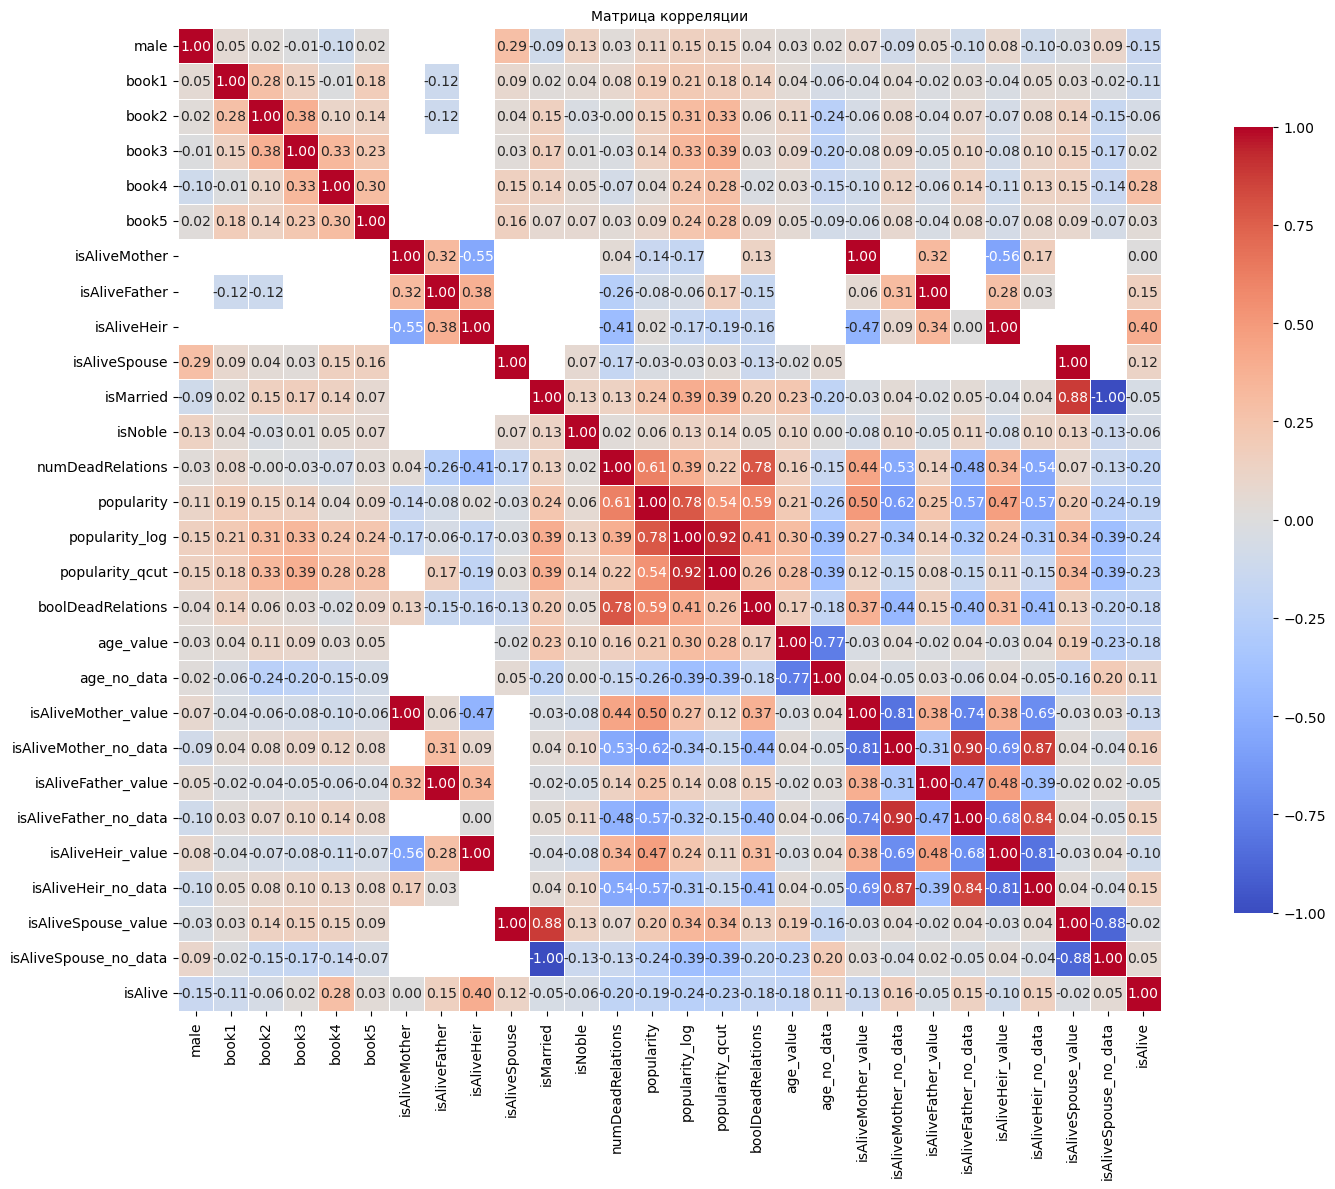

In [799]:
plt.figure(figsize=(16, 12))

sns.heatmap(
    df_corr,
    annot=True,
    fmt='.2f', 
    cmap='coolwarm', 
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8}
)

plt.title('Матрица корреляции', fontsize=10)
plt.tight_layout()

plt.show();

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [800]:
df_corr_with_target = df_corr['isAlive'].drop('isAlive').sort_values(ascending=False)
pd.DataFrame(df_corr_with_target).round(6)

,isAlive
isAliveHeir,0.395285
book4,0.284014
isAliveMother_no_data,0.159302
isAliveFather,0.154983
isAliveHeir_no_data,0.152124
isAliveFather_no_data,0.145771
isAliveSpouse,0.122341
age_no_data,0.113629
isAliveSpouse_no_data,0.049381
book5,0.032531


**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, которые вы отобрали для включения в модель, и `y`, которая будет хранить только значения целевой переменной.

In [801]:
X = data.drop('isAlive', axis=1).copy()
y = data['isAlive']

**Задание 1.10.** Разделите датасет обучащую и валидационные части (train и val) при помощи функции `train_test_split` (https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [802]:
from sklearn.model_selection import train_test_split

In [803]:
data['isAlive'].value_counts(normalize=True)

isAlive
1    0.77842
0    0.22158
Name: proportion, dtype: float64

Классы в целевой переменной 'isAlive' несбалансировны. Применим stratify при разбиении на тренировочную и тестовую выборки

In [804]:
# не забудьте в функции train_test_split задать параметр random_state,
# чтобы обеспечить повторяемость разбиения выборки на train и validation части.
# Это позволит сравнивать метрики моделей с различными методами подготовки признаков

X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y
)

Линейные модели чувствительны к масштабу, поэтому будет полезным масштабировать признаки

In [805]:
from sklearn.preprocessing import StandardScaler

In [806]:
std_scaler = StandardScaler()

X_train_scaled = std_scaler.fit_transform(X_train)
X_val_scaled = std_scaler.transform(X_val)

ValueError: could not convert string to float: 'Mandon Moore'

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.**


Вы можете работать с одной из предложенных моделей из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


Однако в этом домашнем задании мы предлагаем выбрать и поработать с моделью `LogisticRegression`.

In [ ]:
from sklearn.linear_model import LogisticRegression

Импортируйте остальные модели из библиотеки `sklearn`. Чтобы понять как это сделать, воспользуйтесь официальный документацией `sklearn` $→$ [тык](https://scikit-learn.org/dev/user_guide.html). По ключевому названию модели, вы сможете найти необходимую информацию о том, как можно импортировать модель из библиотеки.

In [ ]:
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [ ]:
# Шаг 1. создание модели
log_model = LogisticRegression(max_iter=1000, random_state=42)

# Шаг 2. обучение модели
log_model.fit(X_train_scaled, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = log_model.predict(X_val_scaled)

## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [ ]:
from sklearn.metrics import accuracy_score

В качестве примера, посчитаем метрику accuracy для модели `LogisticRegression`

In [ ]:
# Шаг 3. Предсказание на тестовых данных

# ваш код здесь

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy = accuracy_score(y_val, y_pred)
print("Accuracy : %.4f" % accuracy)

Возможно, вы решите вернуться на несколько шагов и попробовать другие варианты преобразования и подбора признаков в модель. **Выберите** лучшую модель.

### Тестовый датасет

В самом начале нашего домашнего задания мы скачивали тестовый датасет. Загрузите его в Pandas DataFrame при помощи функции read_csv

In [ ]:
df_test = pd.read_csv(PATH + 'game_of_thrones_test.csv', index_col='S.No')

По аналогии с тем, как мы работали с обучающим датасетом, давайте посмотрим в тестовом датасете на статистики признаков с разными типами данных  

In [ ]:
#Подсказка
df_test.loc[df_test['age']<0] # Находим данные с ошибками в дате рождения и возрасте

In [ ]:
#Вы можете аккуратно поправить тестовые данные, воспользовавшись, например следующим кодом:
df_test.loc[df_test['S.No'] == 1685, 'dateOfBirth'] = 278.
df_test.loc[df_test['S.No'] == 1685, 'age'] = 0.
# замены в строке 1685: dateOfBirth -> 278. и age -> 0.
df_test.loc[df_test['S.No'] == 1869, 'dateOfBirth'] = 299.
df_test.loc[df_test['S.No'] == 1869, 'age'] = 0.
# замены в строке 1869: dateOfBirth -> 299. и age -> 0.

Преобразуйте признаки в тестовом датасете по тому же пайплайну, как вы преобразовывали обучающие данные. Примените вашу лучшую модель на тестовом датасете для получения прогноза целевой переменной `isAlive`

In [ ]:
# Формирование X_test
X_test = df_test[selected_features].fillna(0)

In [ ]:
# Масштабирование
X_test_scaled = std_scaler.transform(X_test)

In [ ]:
# Предсказание
y_test_pred = log_model.predict(X_test_scaled)

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [ ]:
# !gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

In [807]:
# Скачивание submission

FILE_ID = '1M14conWjAW2QLoyCXbHEAy8bql2f99eF'
PATH = os.path.join(FOLDER, 'submission.csv')

# Проверка наличия файла и скачивание по необходимости
if not os.path.exists(PATH):
    gdown.download(f'https://drive.google.com/uc?id={FILE_ID}', PATH, quiet=True)
    print('Файл скачан:', PATH)
else:
    print('Файл уже скачан')

Файл скачан: content\submission.csv


In [ ]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [ ]:
submission

,isAlive
S.No,
1558,0
1559,0
1560,0
1561,0
1562,0
...,...
1942,0
1943,0
1944,0


Как сохранить измененный Pandas DataFrame в csv файл:

In [ ]:
# submission.to_csv("/content/new_submission.csv", index=False)

In [ ]:
submission['isAlive'] = y_test_pred

In [ ]:
submission_name = 'new_submission'
submission.to_csv(PATH + f'{submission_name}.csv', index=False)

In [ ]:
# Проверим несколько строк submission

submission_view = pd.read_csv(PATH + f'{submission_name}.csv')

print(submission_view.head())

   isAlive
0        0
1        1
2        1
3        1
4        1


# Поиск лучшей модели и ее параметров

По сетке

In [ ]:
from sklearn.model_selection import GridSearchCV

# Сетка с перебором моделей и их параметров
models = {
    'LogisticRegression': {
        'model': LogisticRegression(max_iter=1000, random_state=42),
        'params': {
            'C': [0.1, 1, 10, 100],
            'solver': ['liblinear', 'lbfgs']
        },
        'scale': True
    },
    'RandomForest': {
        'model': RandomForestClassifier(random_state=42),
        'params': {
            'n_estimators': [100, 200],
            'max_depth': [5, 10, None],
            'min_samples_split': [2, 5]
        },
        'scale': False
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'n_neighbors': [3, 5, 7, 9],
            'weights': ['uniform', 'distance']
        },
        'scale': True
    },
}

best_model = None
best_score = 0
best_params = None
best_name = None

for name, config in models.items():
    print(f'Модель {name}')
    gs = GridSearchCV(config['model'], config['params'], cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    
    gs.fit(X_train_scaled, y_train)
    print(f'Лучшие параметры: {gs.best_params_}')
    print(f'Лучшая точность: {gs.best_score_:.4f}')

    y_pred = gs.predict(X_val_scaled)
    val_acc = accuracy_score(y_val, y_pred)
    print(f'Лучшая точность на валидации:{val_acc:.4f}\n')
    
    if val_acc > best_score:
        best_score = val_acc
        best_model = gs.best_estimator_
        best_params = gs.best_params_
        best_name = name

print(f'Лучшая модель: {best_name}')
print(f'Лучшие параметры: {best_params}')
print(f'Лучшая точность на валидации: {best_score:.4f}')

Модель LogisticRegression
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры: {'C': 0.1, 'solver': 'liblinear'}
Лучшая точность: 0.8080
Лучшая точность на валидации:0.7917

Модель RandomForest
Fitting 5 folds for each of 12 candidates, totalling 60 fits
Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая точность: 0.8305
Лучшая точность на валидации:0.8109

Модель KNN
Fitting 5 folds for each of 8 candidates, totalling 40 fits
Лучшие параметры: {'n_neighbors': 3, 'weights': 'uniform'}
Лучшая точность: 0.8032
Лучшая точность на валидации:0.7660

Лучшая модель: RandomForest
Лучшие параметры: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
Лучшая точность на валидации: 0.8109


In [ ]:
submission = pd.read_csv(PATH + 'submission.csv', index_col='S.No')
submission['isAlive'] = y_test_pred
submission_name = 'submission_gs'
submission.to_csv(PATH + f'{submission_name}.csv', index=False)

# Optuna

In [ ]:
# !pip install optuna

In [ ]:
import optuna
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score

# Функции objective для каждой модели

def objective_lr(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 1e3, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs']),
        'max_iter': 1000,
        'random_state': 42
    }
    model = LogisticRegression(**params)

    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    score = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

def objective_rf(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 10),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'random_state': 42
    }
    model = RandomForestClassifier(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

def objective_knn(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 15),
        'weights': trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p': trial.suggest_int('p', 1, 2)
    }
    model = KNeighborsClassifier(**params)
    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', model)])
    score = cross_val_score(pipeline, X_train_scaled, y_train, cv=5, scoring='accuracy').mean()
    return score

# Оптимизация для каждой модели
studies = {}
models_info = {
    'LogisticRegression': objective_lr,
    'RandomForest': objective_rf,
    'KNN': objective_knn
}

best_models = {}
best_scores = {}

for name, obj_func in models_info.items():
    print(f'Модель {name}')
    study = optuna.create_study(direction='maximize')
    study.optimize(obj_func, n_trials=100, show_progress_bar=True)
    best_params = study.best_params
    best_score = study.best_value
    print(f'Лучшие параметры для {name}: {best_params}')
    print(f'Лучшая точность: {best_score:.4f}\n')

    if name == 'LogisticRegression':
        clf = LogisticRegression(**best_params, max_iter=1000, random_state=42)
    elif name == 'KNN':
        clf = KNeighborsClassifier(**best_params)
    elif name == 'RandomForest':
        clf = RandomForestClassifier(**best_params, random_state=42)
    pipeline = Pipeline([('scaler', StandardScaler()), ('clf', clf)])
    pipeline.fit(X_train_scaled, y_train)
    best_models[name] = pipeline

    best_scores[name] = best_score

# Оценка на валидационной выборке
print('Оценка на валидации:')
best_val_acc = 0
best_model_name = None
for name, model in best_models.items():
    y_pred = model.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    print(f'{name}: точность на валидации = {acc:.4f}')
    if acc > best_val_acc:
        best_val_acc = acc
        best_model_name = name

[I 2026-03-27 21:02:32,287] A new study created in memory with name: no-name-3579aeab-3158-47d9-8a42-8818baa4eb07


Модель LogisticRegression


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-27 21:02:32,346] Trial 0 finished with value: 0.8024096385542168 and parameters: {'C': 55.32163259998678, 'solver': 'liblinear'}. Best is trial 0 with value: 0.8024096385542168.
[I 2026-03-27 21:02:32,384] Trial 1 finished with value: 0.804016064257028 and parameters: {'C': 0.014352560425650985, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.804016064257028.
[I 2026-03-27 21:02:32,422] Trial 2 finished with value: 0.8008032128514057 and parameters: {'C': 0.588175020215912, 'solver': 'liblinear'}. Best is trial 1 with value: 0.804016064257028.
[I 2026-03-27 21:02:32,495] Trial 3 finished with value: 0.8024096385542168 and parameters: {'C': 10.79389723565948, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.804016064257028.
[I 2026-03-27 21:02:32,549] Trial 4 finished with value: 0.8024096385542168 and parameters: {'C': 191.87680391421782, 'solver': 'lbfgs'}. Best is trial 1 with value: 0.804016064257028.
[I 2026-03-27 21:02:32,600] Trial 5 finished with value: 0.801606425

[I 2026-03-27 21:02:35,455] A new study created in memory with name: no-name-1857d9b9-71ec-4972-838c-76d504316570


...

[I 2026-03-27 21:02:36,482] Trial 0 finished with value: 0.8096385542168674 and parameters: {'n_estimators': 264, 'max_depth': 6, 'min_samples_split': 10, 'min_samples_leaf': 1}. Best is trial 0 with value: 0.8096385542168674.
[I 2026-03-27 21:02:37,207] Trial 1 finished with value: 0.8160642570281125 and parameters: {'n_estimators': 176, 'max_depth': 15, 'min_samples_split': 9, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8160642570281125.
[I 2026-03-27 21:02:37,656] Trial 2 finished with value: 0.8120481927710843 and parameters: {'n_estimators': 113, 'max_depth': 7, 'min_samples_split': 4, 'min_samples_leaf': 3}. Best is trial 1 with value: 0.8160642570281125.
[I 2026-03-27 21:02:38,183] Trial 3 finished with value: 0.8088353413654618 and parameters: {'n_estimators': 133, 'max_depth': 8, 'min_samples_split': 8, 'min_samples_leaf': 4}. Best is trial 1 with value: 0.8160642570281125.
[I 2026-03-27 21:02:38,772] Trial 4 finished with value: 0.8144578313253013 and parameters: {'

[I 2026-03-27 21:04:16,647] A new study created in memory with name: no-name-48ead700-bad8-4b8e-88ff-924c641a251b


Модель KNN


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-03-27 21:04:16,716] Trial 0 finished with value: 0.8072289156626505 and parameters: {'n_neighbors': 8, 'weights': 'distance', 'p': 1}. Best is trial 0 with value: 0.8072289156626505.
[I 2026-03-27 21:04:16,759] Trial 1 finished with value: 0.8080321285140564 and parameters: {'n_neighbors': 10, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.8080321285140564.
[I 2026-03-27 21:04:16,799] Trial 2 finished with value: 0.8080321285140564 and parameters: {'n_neighbors': 5, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.8080321285140564.
[I 2026-03-27 21:04:16,860] Trial 3 finished with value: 0.7991967871485943 and parameters: {'n_neighbors': 3, 'weights': 'distance', 'p': 2}. Best is trial 1 with value: 0.8080321285140564.
[I 2026-03-27 21:04:16,924] Trial 4 finished with value: 0.8032128514056225 and parameters: {'n_neighbors': 9, 'weights': 'distance', 'p': 2}. Best is trial 1 with value: 0.8080321285140564.
[I 2026-03-27 21:04:16,981] Trial 5 finished w

In [ ]:
print(f'Лучшая модель на валидации: {best_model_name} с accuracy = {best_val_acc:.4f}')

# Финальное предсказание на тестовых данных с лучшей моделью
final_model = best_models[best_model_name]
y_test_pred = final_model.predict(X_test_scaled)

Лучшая модель на валидации: RandomForest с accuracy = 0.8141


In [ ]:
submission = pd.read_csv(PATH + 'submission.csv', index_col='S.No')
submission['isAlive'] = y_test_pred
submission_name = 'submission_optuna'
submission.to_csv(PATH + f'{submission_name}.csv', index=False)

![image.png](attachment:image.png)

Accuracy вашего решения равен 0.7377892030848329. Это дает вам 5.0 баллов.